# BKG Studies

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate


In [10]:
# Constants
vr = "18"
npl, fw, fh = 2, 16, 9
n_scl = 1#200000

# Test

In [11]:
# test

npl =2
output_t2 = coffea.util.load("outputs/BKG_test2.coffea")
output_t4 = coffea.util.load("outputs/BKG_test4.coffea")


test2 = ["2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_1p2GeV_0p019mm"]
test4 = ["4Mu_200GeV_5p0GeV_200p0mm", "4Mu_500GeV_0p25GeV_0p004mm"]

channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_2lj", "bkg_study_isopdisp_2lj_dPhi_4mu", "bkg_study_isopdisp_2lj_dPhi_2mu2e",]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]
ch5 = channels[4]

In [12]:
output_t2[test2[0]]["cutflow"][ch5].print_table()
print()
output_t2[test2[1]]["cutflow"][ch5].print_table()
print()
output_t4[test4[0]]["cutflow"][ch4].print_table()

cut name                raw N    weighted N    weighted %
--------------------  -------  ------------  ------------
None                  68631.0          59.8         100.0
pass triggers         14227.0          12.4          20.7
PV filter             14227.0          12.4          20.7
>=2 LJs                6278.0           5.5           9.1
>=1 egm_ljs            4460.0           3.9           6.5
>=1 mu_ljs             3261.0           2.8           4.8
dPhi(LJ_0, LJ_1) > 2   1617.0           1.4           2.4

cut name                 raw N    weighted N    weighted %
--------------------  --------  ------------  ------------
None                  204771.0          59.8         100.0
pass triggers          95751.0          28.0          46.8
PV filter              95751.0          28.0          46.8
>=2 LJs                89607.0          26.2          43.8
>=1 egm_ljs             6128.0           1.8           3.0
>=1 mu_ljs               327.0           0.1           0.2
dPhi(

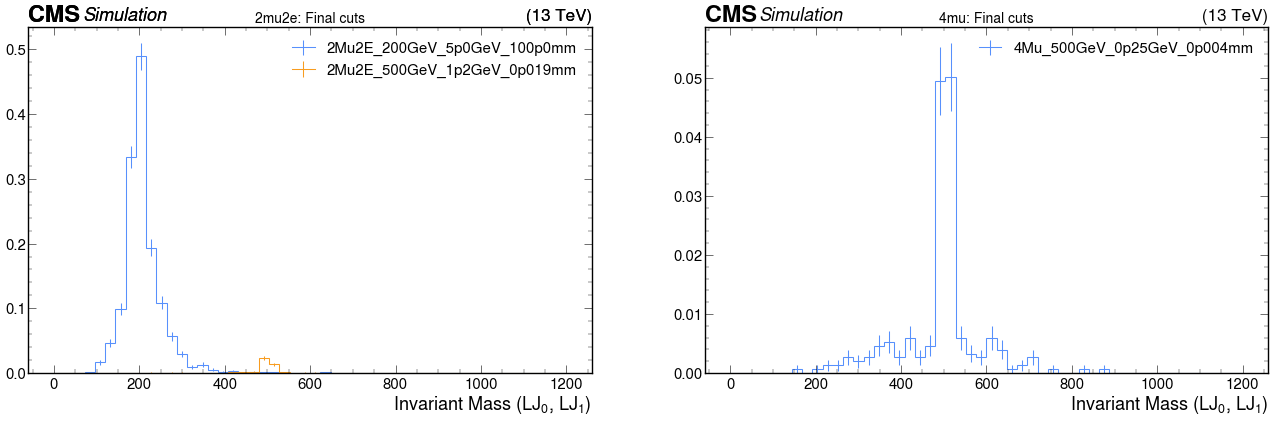

In [18]:
# test
HistToPlot = ["lj_lj_invmass"]
for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    plt.subplot(1, 2, 1)
    for sss in test2:
        utilities.plot(output_t2[sss]["hists"]["mulj_egmlj_invmass"][ch5, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("2mu2e: Final cuts", fontsize=20)

    plt.subplot(1, 2, 2)
    for sss in test4:
        utilities.plot(output_t4[sss]["hists"]["lj_lj_invmass"][ch4, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("4mu: Final cuts", fontsize=20)
# plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

In [45]:
# Signal and BKG files

mxx_2mu = ["2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", "2Mu2E_800GeV_5p0GeV_50p0mm","2Mu2E_1000GeV_5p0GeV_40p0mm",]# Mxx_5_300
mzd_2mu = ["2Mu2E_500GeV_0p25GeV_4p0mm", "2Mu2E_500GeV_1p2GeV_19p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", ] # 500_Mzd_300
lxy_2mu = ["2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_0p19mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_500GeV_1p2GeV_9p6mm", "2Mu2E_500GeV_1p2GeV_19p0mm"] # 500_1.2_Lxy

mxx_4mu = [    "4Mu_200GeV_5p0GeV_200p0mm",    "4Mu_500GeV_5p0GeV_80p0mm",    "4Mu_800GeV_5p0GeV_50p0mm",    "4Mu_1000GeV_5p0GeV_40p0mm",]
mzd_4mu = [    "4Mu_500GeV_0p25GeV_0p004mm",    "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm",]
lxy_4mu = [    "4Mu_500GeV_1p2GeV_0p019mm",     "4Mu_500GeV_1p2GeV_0p19mm",    "4Mu_500GeV_1p2GeV_1p9mm",    "4Mu_500GeV_1p2GeV_9p6mm",    "4Mu_500GeV_1p2GeV_19p0mm",]


bkgdyj = ["DYJetsToMuMu_M10to50",    "DYJetsToMuMu_M50",]
bkgttj = ["TTJets"]
bkgqcd = ["QCD_Pt15To20",    "QCD_Pt20To30",    "QCD_Pt30To50",    "QCD_Pt50To80",    "QCD_Pt80To120",]
bkgocd = ["QCD_Pt120To170",    "QCD_Pt170To300",    "QCD_Pt300To470",    "QCD_Pt470To600",    "QCD_Pt600To800", "QCD_Pt1000",] # "QCD_Pt800To1000", # does not work
allqcd = bkgqcd + bkgocd

In [40]:
# Selections

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_2lj", "bkg_study_isopdisp_2lj_dPhi_4mu", "bkg_study_isopdisp_2lj_dPhi_2mu2e",]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]
ch5 = channels[4]

cha = [ch1, ch2, ch3, ch4, ch5]
col = ["r", "g", "b"]

In [40]:
# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_dyj = coffea.util.load("outputs/BKG_bkgdyj_" + vr + ".coffea")
output_ttj = coffea.util.load("outputs/BKG_bkgttj_" + vr + ".coffea")
output_qcd = coffea.util.load("outputs/BKG_bkgqcd_" + vr + ".coffea")
output_ocd = coffea.util.load("outputs/BKG_bkgocd_" + vr + ".coffea")

In [41]:
#printing cutflows
output_2mu[mxx_2mu[0]]["cutflow"][ch5].print_table()
print()
output_4mu[mxx_4mu[0]]["cutflow"][ch4].print_table()
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

cut name                raw N    weighted N    weighted %
--------------------  -------  ------------  ------------
None                  13382.0          59.8         100.0
pass triggers          2787.0          12.5          20.8
PV filter              2787.0          12.5          20.8
>=2 LJs                1213.0           5.4           9.1
>=1 egm_ljs             868.0           3.9           6.5
>=1 mu_ljs              624.0           2.8           4.7
dPhi(LJ_0, LJ_1) > 2    288.0           1.3           2.2

cut name                raw N    weighted N    weighted %
--------------------  -------  ------------  ------------
None                  17492.0          59.8         100.0
pass triggers         12035.0          41.2          68.8
PV filter             12035.0          41.2          68.8
>=2 LJs                6836.0          23.4          39.1
>=2 mu_ljs             4163.0          14.2          23.8
dPhi(LJ_0, LJ_1) > 2   2017.0           6.9          11.5


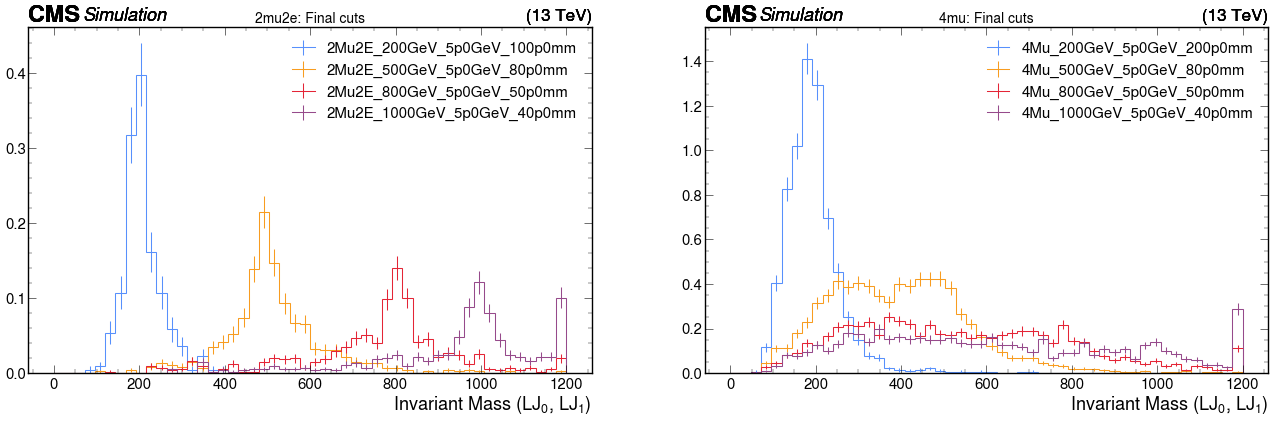

In [42]:
# Comparing signal for the two channels in mxx

HistToPlot = ["lj_lj_invmass"]
for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    plt.subplot(1, 2, 1)
    for sss in mxx_2mu:
        utilities.plot(output_2mu[sss]["hists"][thisHist][ch5, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("2mu2e: Final cuts", fontsize=20)

    plt.subplot(1, 2, 2)
    for sss in mxx_4mu:
        utilities.plot(output_4mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("4mu: Final cuts", fontsize=20)
plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

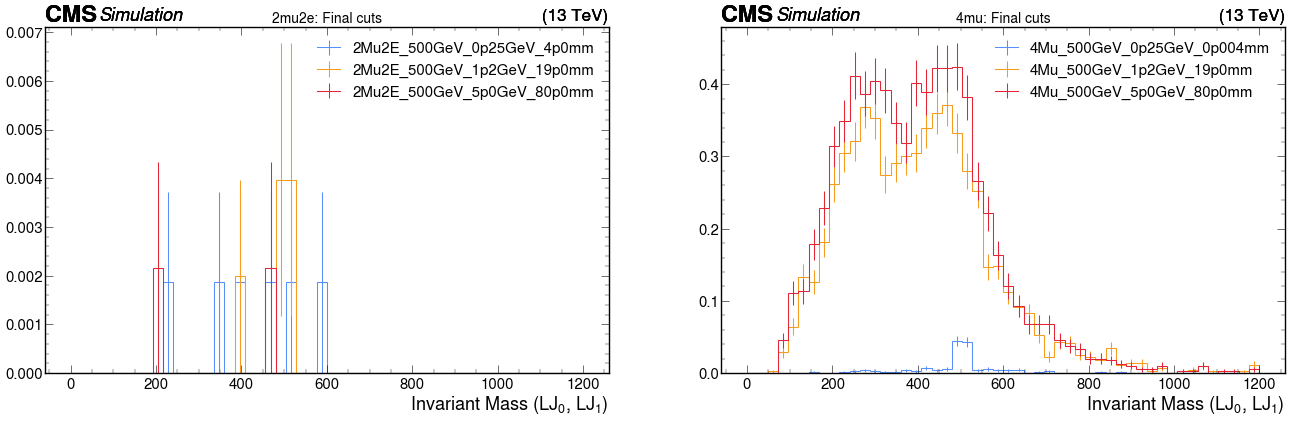

In [43]:
# Comparing signal for the two channels in mzd

HistToPlot = ["lj_lj_invmass"]
for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    plt.subplot(1, 2, 1)
    for sss in mzd_2mu:
        utilities.plot(output_2mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("2mu2e: Final cuts", fontsize=20)

    plt.subplot(1, 2, 2)
    for sss in mzd_4mu:
        utilities.plot(output_4mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("4mu: Final cuts", fontsize=20)

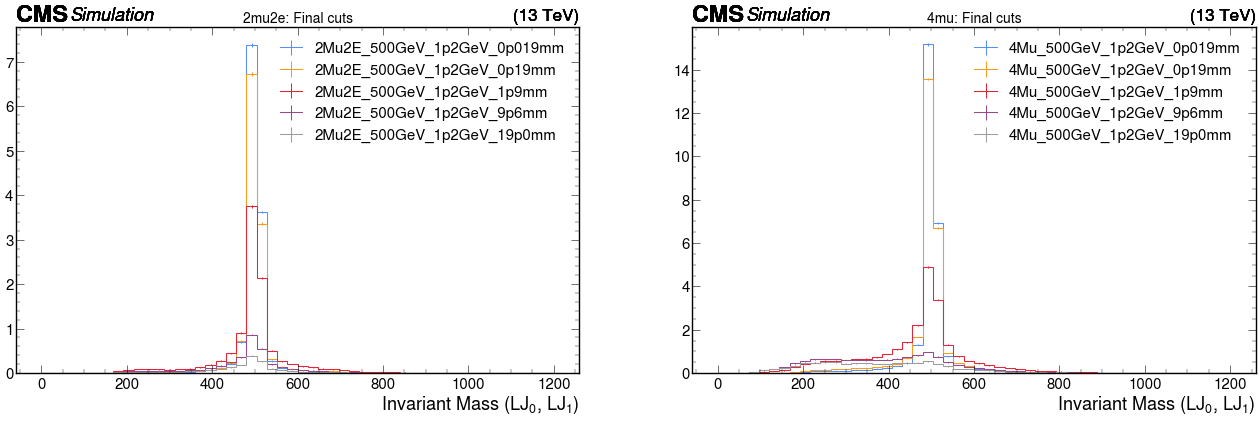

In [7]:
# Comparing signal for the two channels in lxy

HistToPlot = ["lj_lj_invmass"]
for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    plt.subplot(1, 2, 1)
    for sss in lxy_2mu:
        utilities.plot(output_2mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("2mu2e: Final cuts", fontsize=20)

    plt.subplot(1, 2, 2)
    for sss in lxy_4mu:
        utilities.plot(output_4mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc=0)
    plt.title("4mu: Final cuts", fontsize=20)

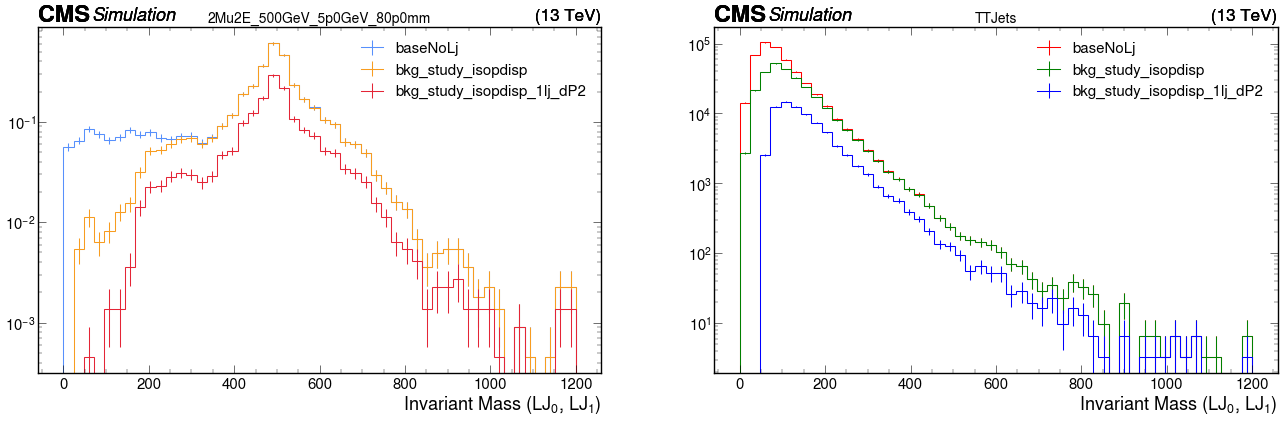

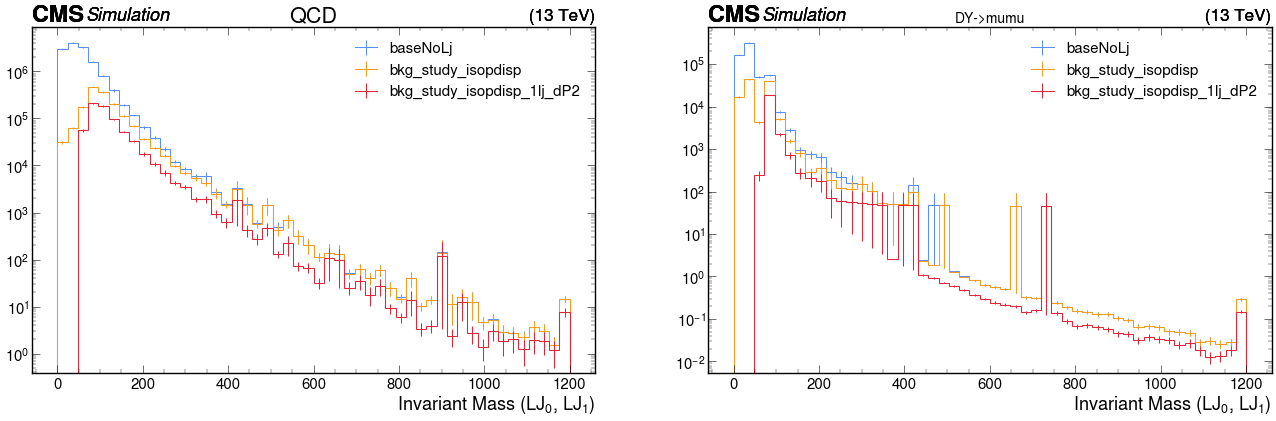

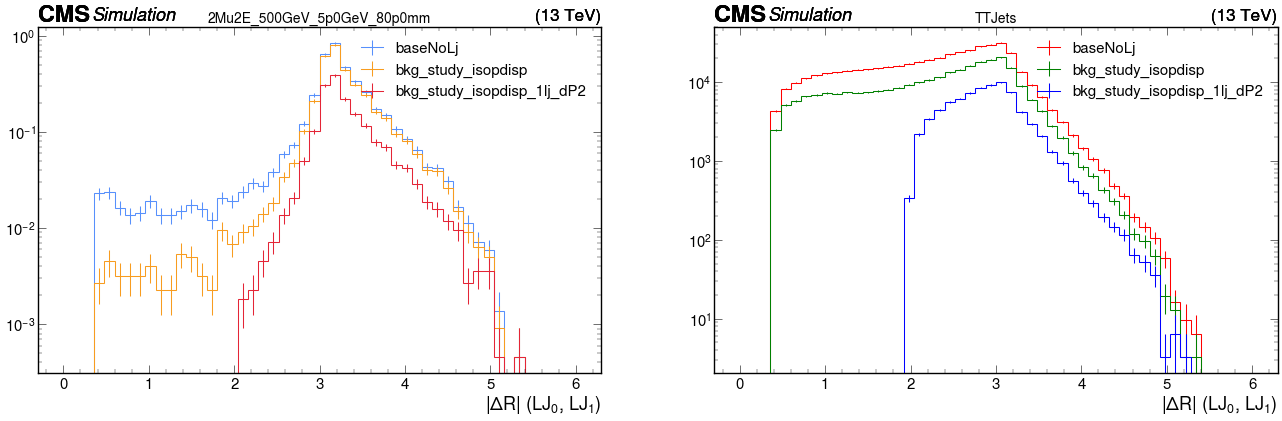

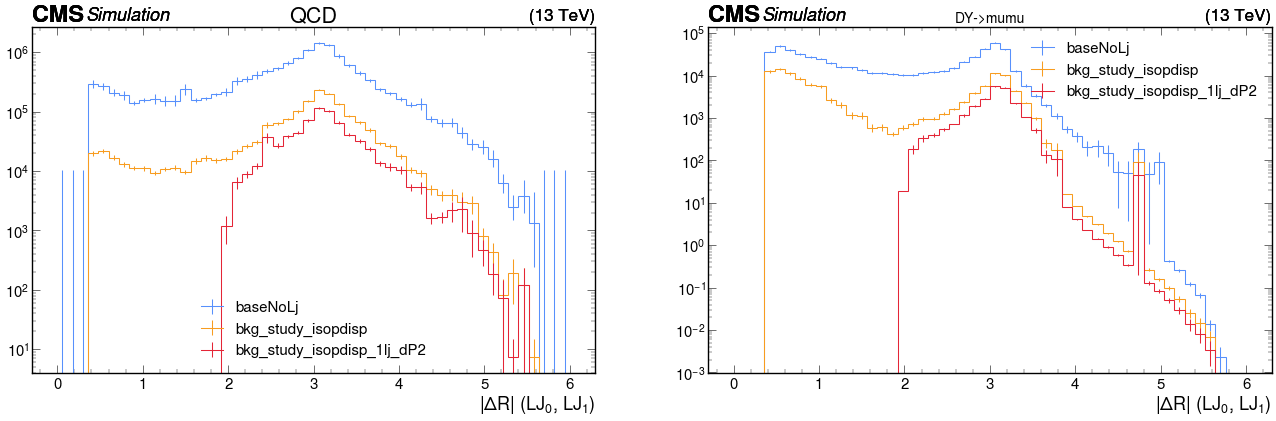

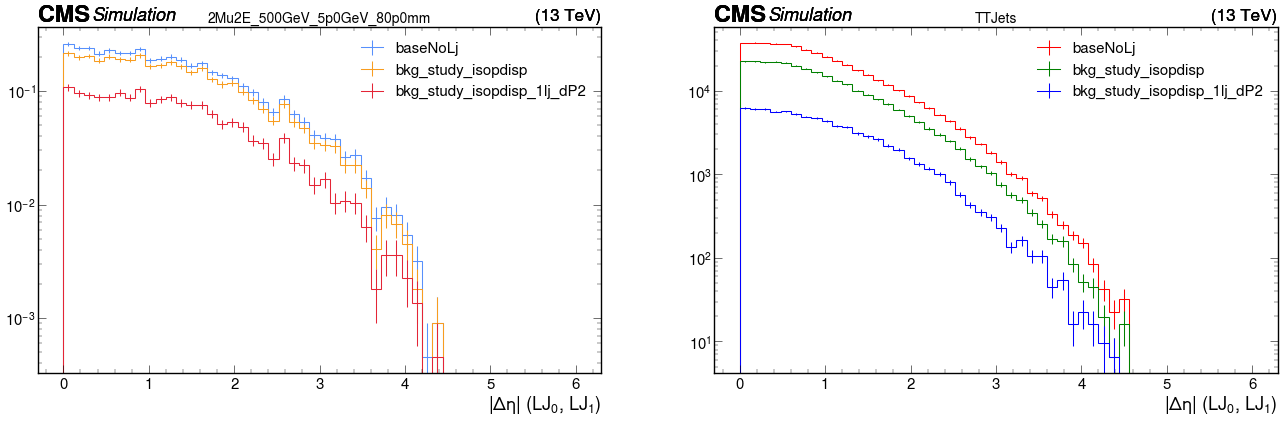

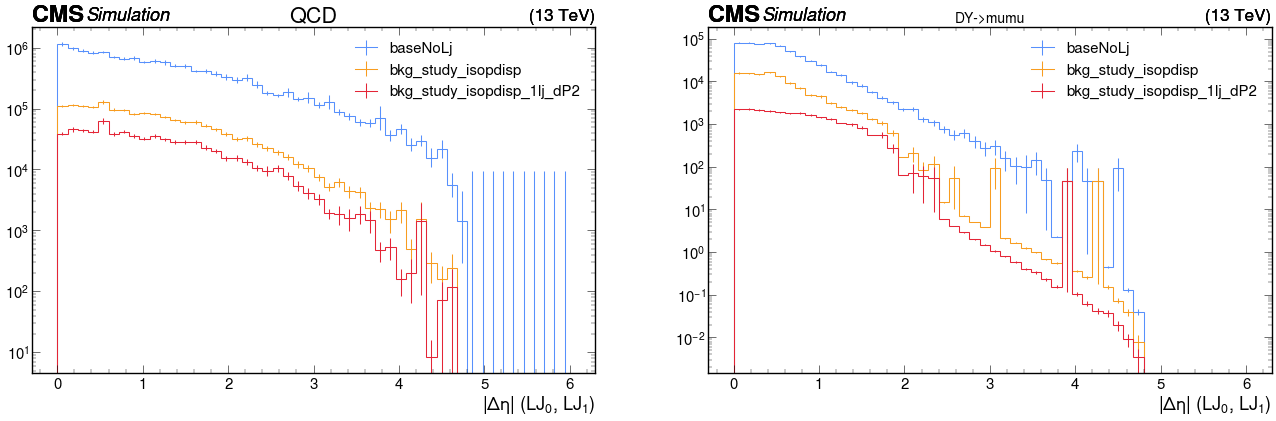

In [8]:
# Backgrund for different selections

# HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]
HistToPlot = ["lj_lj_invmass", "lj_lj_absdR", "lj_lj_absdeta"]
for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))

    # fig, axes = plt.subplots(1, 2, figsize=(32, 8))
    plt.subplot(1, 2, 1)
    for i, ch in enumerate(cha):
        utilities.plot(output_2mu[mxx_2mu[1]]["hists"][thisHist][ch, ::2j], label = ch, density=False,)
    plt.legend(alignment="left", loc="upper right")
    plt.title(mxx_2mu[1], fontsize=20)
    plt.yscale("log")
    
    plt.subplot(1, 2, 2)
    for i, ch in enumerate(cha):
        utilities.plot(output_ttj[bkgttj[0]]["hists"][thisHist][ch, ::2j] , label = ch, density=False,color= col[i] )
    plt.legend(alignment="left", loc="upper right")
    plt.title(bkgttj[0], fontsize=20)
    plt.yscale("log")

    plt.subplots(1, npl, figsize=(npl*fw, fh))
    plt.subplot(1, 2, 1)
    for i, ch in enumerate(cha):
        QCD = 0
        for sss in allqcd:
            if sss in bkgqcd:  QCD = QCD + output_qcd[sss]["hists"][thisHist][ch, ::2j]
            elif sss in bkgocd: QCD = QCD + output_ocd[sss]["hists"][thisHist][ch, ::2j]
        utilities.plot(QCD, density=False, label=ch)
    plt.title(r"QCD")
    plt.legend(alignment="left", loc=0)
    plt.yscale("log")
    
    plt.subplot(1, 2, 2)
    for i, ch in enumerate(cha):
        dyj = 0
        for sss in bkgdyj:
            dyj = dyj + output_dyj[sss]["hists"][thisHist][ch, ::2j]
        utilities.plot(dyj, density=False, label=ch)
        
    plt.legend(alignment="left", loc="upper right")
    plt.title("DY->mumu", fontsize=20)
    plt.yscale("log")

KeyError: "'bkg_study_isopdisp_2lj_dPhi_4mu' not in axis"

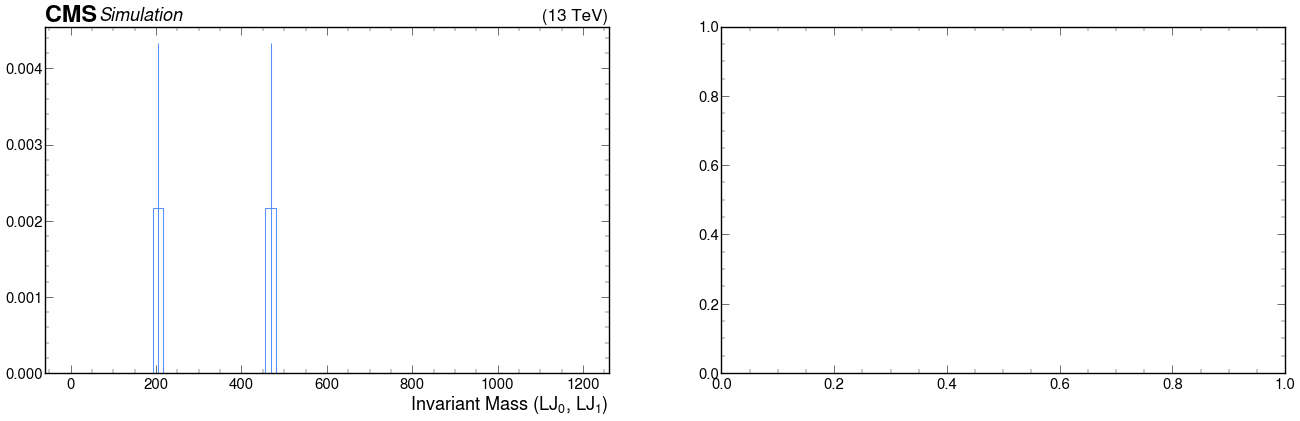

In [39]:
#signal and background for one sample

HistToPlot = ["lj_lj_invmass"]
for thisHist in HistToPlot:

    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, 2, 1)
    utilities.plot(output_2mu[mxx_2mu[1]]["hists"][thisHist][ch4, ::2j], label = "sig", density=False,)
    utilities.plot(output_ttj[bkgttj[0]]["hists"][thisHist][ch4, ::2j] , label = "TTJets", density=False, color= "b")
    
    dyj = 0
    for sss in bkgdyj:
        dyj = dyj + output_dyj[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
    utilities.plot(dyj, density=False, label="DYJ", color= "r")

    QCD = 0
    for sss in allqcd:
        if sss in bkgqcd:  QCD = QCD + output_qcd[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
        elif sss in bkgocd: QCD = QCD + output_ocd[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
    utilities.plot(QCD, density=False, label="QCD", color= "g")
    
    plt.legend(alignment="left", loc="upper right")
    plt.title(mxx_2mu[1], fontsize=20)
    plt.yscale("log")

    
    plt.subplot(1, 2, 2)
    utilities.plot(output_4mu[mxx_4mu[1]]["hists"][thisHist][ch4, ::2j], label = "sig", density=False,)
    utilities.plot(output_ttj[bkgttj[0]]["hists"][thisHist][ch4, ::2j] , label = "TTJets", density=False, color= "b")
    
    dyj = 0
    for sss in bkgdyj:
        dyj = dyj + output_dyj[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
    utilities.plot(dyj, density=False, label="DYJ", color= "r")

    QCD = 0
    for sss in allqcd:
        if sss in bkgqcd:  QCD = QCD + output_qcd[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
        elif sss in bkgocd: QCD = QCD + output_ocd[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
    utilities.plot(QCD, density=False, label="QCD", color= "g")
    
    plt.legend(alignment="left", loc="upper right")
    plt.title(mxx_4mu[1], fontsize=20)
    plt.yscale("log")


In [10]:
raise SystemExit("Notebook stopped intentionally after this cell.")

SystemExit: Notebook stopped intentionally after this cell.

/usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


- ### 11: Adding photon cross cleaning and Switching to Dask. Running over all 2mu, all 4mu and 200 BKG files

In [ ]:
vr = "11"
# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_bkg = coffea.util.load("outputs/BKG_bkg_"  +  vr  + ".coffea")


#printing cutflows
output_2mu[sig_2mu[2]]["cutflow"][ch2].print_table(unweighted=True)
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]

for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")

    plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

- ### 12: Adding nlj cuts. Running all 2mu2e, 4mu, and 700 bkg files.
- ### 14: Running over all files in all samples

In [ ]:
vr = "12" #,  
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj"]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_bkg = coffea.util.load("outputs/BKG_bkg_"  +  vr  + ".coffea")

#printing cutflows
output_2mu[sig_2mu[2]]["cutflow"][ch2].print_table(unweighted=True)
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]

for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch2, ::2j], label = sss, density=False,)

    QCD, DYJ, TTJ = 0, 0, 0
    for sss in bkg:
        if "DYJ" in sss:
            DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "QCD" in sss:
            QCD = QCD + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
        elif "TTJ" in sss:
            TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")

    # plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

# 13 Adding the $\Delta \Phi$ cut. Settling on 4 2mu, 4mu, and all BKG samples. Running over all files 

In [ ]:
vr = "13" # First Try
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj", "bkg_study_isopdisp_1lj_dP2"]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
# output_bkg = coffea.util.load("outputs/BKG_bkg_"  +  vr  + ".coffea")

#printing cutflows
output_2mu[sig_2mu[0]]["cutflow"][ch2].print_table()
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]

for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)

    # QCD, DYJ, TTJ = 0, 0, 0
    # for sss in bkg:
    #     if "DYJ" in sss:
    #         DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    #     elif "QCD" in sss:
    #         QCD = QCD + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    #     elif "TTJ" in sss:
    #         TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch1, ::2j]
    
    # utilities.plot(DYJ, label = "DY", density=False, color="blue")
    # utilities.plot(QCD, label = "QCD", density=False, color="green")
    # utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in sig_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    for sss in sig_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)

    # QCD, DYJ, TTJ = 0, 0, 0
    # for sss in bkg:
    #     if "DYJ" in sss:
    #         DYJ = DYJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    #     elif "QCD" in sss:
    #         QCD = QCD + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    #     elif "TTJ" in sss:
    #         TTJ = TTJ + output_bkg[sss]["hists"][thisHist][ch2, ::2j]
    
    # utilities.plot(DYJ, label = "DY", density=False, color="blue")
    # utilities.plot(QCD, label = "QCD", density=False, color="green")
    # utilities.plot(TTJ, label = "TTJ", density=False, color="black")
    plt.legend(alignment="left", loc="upper right")

    # plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

In [ ]:
vr = "15" #signal only

mxx_2mu = ["2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", "2Mu2E_800GeV_5p0GeV_50p0mm","2Mu2E_1000GeV_5p0GeV_40p0mm",]# Mxx_5_300
mzd_2mu = ["2Mu2E_500GeV_0p25GeV_4p0mm", "2Mu2E_500GeV_1p2GeV_19p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", ] # 500_Mzd_300
lxy_2mu = ["2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_0p19mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_500GeV_1p2GeV_9p6mm", "2Mu2E_500GeV_1p2GeV_19p0mm"] # 500_1.2_Lxy

mxx_4mu = [    "4Mu_200GeV_5p0GeV_200p0mm",    "4Mu_500GeV_5p0GeV_80p0mm",    "4Mu_800GeV_5p0GeV_50p0mm",    "4Mu_1000GeV_5p0GeV_40p0mm",]
mzd_4mu = [    "4Mu_500GeV_0p25GeV_0p004mm",    "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm",]
lxy_4mu = [    "4Mu_500GeV_1p2GeV_0p019mm",     "4Mu_500GeV_1p2GeV_0p19mm",    "4Mu_500GeV_1p2GeV_1p9mm",    "4Mu_500GeV_1p2GeV_9p6mm",    "4Mu_500GeV_1p2GeV_19p0mm",]

bkgdyj = ["DYJetsToMuMu_M10to50",    "DYJetsToMuMu_M50",]
bkgttj = ["TTJets"]
bkgqcd = ["QCD_Pt15To20",    "QCD_Pt20To30",    "QCD_Pt30To50",    "QCD_Pt50To80",    "QCD_Pt80To120",]
bkgocd = ["QCD_Pt120To170",    "QCD_Pt170To300",    "QCD_Pt300To470",    "QCD_Pt470To600",    "QCD_Pt600To800", "QCD_Pt1000",]
              # "QCD_Pt800To1000", # does not work

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj", "bkg_study_isopdisp_1lj_dP2", ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_dyj = coffea.util.load("outputs/BKG_bkgdyj_" + vr  + ".coffea")
output_ttj = coffea.util.load("outputs/BKG_bkgttj_" + vr  + ".coffea")
output_qcd = coffea.util.load("outputs/BKG_bkgqcd_" + vr  + ".coffea")

#printing cutflows
# output_2mu[sig_2mu[0]]["cutflow"][ch2].print_table()
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]



for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in mxx_2mu:
        utilities.plot(output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in mxx_4mu:
        utilities.plot(output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in mxx_2mu:
        utilities.plot(output_2mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    for sss in mxx_4mu:
        utilities.plot(output_4mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    plt.legend(alignment="left", loc="upper right")

    # plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

In [ ]:
vr = "15" # Adding background

mxx_2mu = ["2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", "2Mu2E_800GeV_5p0GeV_50p0mm","2Mu2E_1000GeV_5p0GeV_40p0mm",]# Mxx_5_300
mzd_2mu = ["2Mu2E_500GeV_0p25GeV_4p0mm", "2Mu2E_500GeV_1p2GeV_19p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", ] # 500_Mzd_300
lxy_2mu = ["2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_0p19mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_500GeV_1p2GeV_9p6mm", "2Mu2E_500GeV_1p2GeV_19p0mm"] # 500_1.2_Lxy

mxx_4mu = [    "4Mu_200GeV_5p0GeV_200p0mm",    "4Mu_500GeV_5p0GeV_80p0mm",    "4Mu_800GeV_5p0GeV_50p0mm",    "4Mu_1000GeV_5p0GeV_40p0mm",]
mzd_4mu = [    "4Mu_500GeV_0p25GeV_0p004mm",    "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm",]
lxy_4mu = [    "4Mu_500GeV_1p2GeV_0p019mm",     "4Mu_500GeV_1p2GeV_0p19mm",    "4Mu_500GeV_1p2GeV_1p9mm",    "4Mu_500GeV_1p2GeV_9p6mm",    "4Mu_500GeV_1p2GeV_19p0mm",]

bkgdyj = ["DYJetsToMuMu_M10to50",    "DYJetsToMuMu_M50",]
bkgttj = ["TTJets"]
bkgqcd = ["QCD_Pt15To20",    "QCD_Pt20To30",    "QCD_Pt30To50",    "QCD_Pt50To80",    "QCD_Pt80To120",]
bkgocd = ["QCD_Pt120To170",    "QCD_Pt170To300",    "QCD_Pt300To470",    "QCD_Pt470To600",    "QCD_Pt600To800", "QCD_Pt1000",]
              # "QCD_Pt800To1000", # does not work

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj", "bkg_study_isopdisp_1lj_dP2", ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_dyj = coffea.util.load("outputs/BKG_bkgdyj_" + vr  + ".coffea")
output_ttj = coffea.util.load("outputs/BKG_bkgttj_" + vr  + ".coffea")
output_qcd = coffea.util.load("outputs/BKG_bkgqcd_" + vr  + ".coffea")

#printing cutflows
# output_2mu[sig_2mu[0]]["cutflow"][ch2].print_table()
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 2, 18, 10
n_scl = 1#200000

HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]



for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))
    
    plt.subplot(1, npl, 1)
    for sss in mxx_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
    for sss in mxx_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)

    DYJ = 0
    for sss in bkgdyj:
        DYJ = DYJ + output_dyj[sss]["hists"][thisHist][ch1, ::2j]
    
    
    QCD = 0
    for sss in bkgqcd:
        QCD = QCD + output_qcd[sss]["hists"][thisHist][ch1, ::2j]
 
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(output_ttj["TTJets"]["hists"][thisHist][ch1, ::2j] , label = "TTJ", density=False, color="black")
    utilities.plot(QCD, label = "QCD", density=False, color="green")

    plt.legend(alignment="left", loc="upper right")


    
    plt.subplot(1, npl, 2)
    for sss in mxx_2mu:
        utilities.plot(n_scl*output_2mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)
    for sss in mxx_4mu:
        utilities.plot(n_scl*output_4mu[sss]["hists"][thisHist][ch4, ::2j], label = sss, density=False,)

    DYJ = 0
    for sss in bkgdyj:
        DYJ = DYJ + output_dyj[sss]["hists"][thisHist][ch4, ::2j]
        
    QCD = 0
    for sss in bkgqcd:
        QCD = QCD + output_qcd[sss]["hists"][thisHist][ch4, ::2j]
        
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    utilities.plot(output_ttj["TTJets"]["hists"][thisHist][ch4, ::2j] , label = "TTJ", density=False, color="black")
    utilities.plot(QCD, label = "QCD", density=False, color="green")
    
    plt.legend(alignment="left", loc="upper right")

    # plt.savefig(f"plots/BKG_{vr}_{thisHist}", bbox_inches="tight")

## SInce background since to be absent from this plot I need to test why that is the case. Is it because the cuts removed it all or just because something is wrong?

In [ ]:
vr = "15" # Backgroung Only

mxx_2mu = ["2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", "2Mu2E_800GeV_5p0GeV_50p0mm","2Mu2E_1000GeV_5p0GeV_40p0mm",]# Mxx_5_300
mzd_2mu = ["2Mu2E_500GeV_0p25GeV_4p0mm", "2Mu2E_500GeV_1p2GeV_19p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", ] # 500_Mzd_300
lxy_2mu = ["2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_0p19mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_500GeV_1p2GeV_9p6mm", "2Mu2E_500GeV_1p2GeV_19p0mm"] # 500_1.2_Lxy

mxx_4mu = [    "4Mu_200GeV_5p0GeV_200p0mm",    "4Mu_500GeV_5p0GeV_80p0mm",    "4Mu_800GeV_5p0GeV_50p0mm",    "4Mu_1000GeV_5p0GeV_40p0mm",]
mzd_4mu = [    "4Mu_500GeV_0p25GeV_0p004mm",    "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm",]
lxy_4mu = [    "4Mu_500GeV_1p2GeV_0p019mm",     "4Mu_500GeV_1p2GeV_0p19mm",    "4Mu_500GeV_1p2GeV_1p9mm",    "4Mu_500GeV_1p2GeV_9p6mm",    "4Mu_500GeV_1p2GeV_19p0mm",]

bkgdyj = ["DYJetsToMuMu_M10to50",    "DYJetsToMuMu_M50",]
bkgttj = ["TTJets"]
bkgqcd = ["QCD_Pt15To20",    "QCD_Pt20To30",    "QCD_Pt30To50",    "QCD_Pt50To80",    "QCD_Pt80To120",]
bkgocd = ["QCD_Pt120To170",    "QCD_Pt170To300",    "QCD_Pt300To470",    "QCD_Pt470To600",    "QCD_Pt600To800", "QCD_Pt1000",]
              # "QCD_Pt800To1000", # does not work

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj", "bkg_study_isopdisp_1lj_dP2", ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

cha = [ch1, ch2, ch3, ch4]
col = ["r", "g", "b", "m"]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_dyj = coffea.util.load("outputs/BKG_bkgdyj_" + vr  + ".coffea")
output_ttj = coffea.util.load("outputs/BKG_bkgttj_" + vr  + ".coffea")
output_qcd = coffea.util.load("outputs/BKG_bkgqcd_" + vr  + ".coffea")
output_ocd = coffea.util.load("outputs/BKG_bkgocd_" + vr  + ".coffea")

# printing cutflows
output_2mu[mxx_2mu[0]]["cutflow"][ch2].print_table()
# output_4mu[sig_4mu[0]]["cutflow"][ch1].print_table(unweighted=True)
# output_bkg[bkg[0]]["cutflow"][ch1].print_table(unweighted=True)

# plt.subplots(1, npl, figsize=(npl*figw, figh))
npl, fw, fh = 3, 18, 10
n_scl = 1#200000


HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]

plt.subplots(1, npl, figsize=(npl*fw, fh))

plt.subplot(1, npl, 1)
for i, ch in enumerate(cha):
    DYJ = 0
    for sss in bkgdyj:
        DYJ = DYJ + output_dyj[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
    utilities.plot(DYJ, label = ch, density=False, color= col[i])
plt.title("DY->mumu")
plt.legend(alignment="left", loc=0)

plt.subplot(1, npl, 2)
for i, ch in enumerate(cha):
    utilities.plot(output_ttj[bkgttj[0]]["hists"]["lj_lj_invmass"][ch, ::2j] , label = ch, density=False,color= col[i] )
plt.title("TTJets")
plt.legend(alignment="left", loc=0)

plt.subplot(1, npl, 3)
for i, ch in enumerate(cha):
    QCD = 0
    for sss in bkgqcd:
        QCD = QCD + output_qcd[sss]["hists"]["lj_lj_invmass"][ch, ::2j]
    utilities.plot(QCD, label = ch, density=False, color= col[i])
plt.title("QCD")
plt.legend(alignment="left", loc=0)





#1 LJ only
plt.subplots(1, npl, figsize=(npl*fw, fh))
plt.subplot(1, npl, 1)
DYJ = 0
for sss in bkgdyj:
    DYJ = DYJ + output_dyj[sss]["hists"]["lj_lj_invmass"][ch3, ::2j]
utilities.plot(DYJ, label = "DYJ", density=False, color= "b")
utilities.plot(output_ttj[bkgttj[0]]["hists"]["lj_lj_invmass"][ch3, ::2j] , label = "TTJ", density=False,color= "m" )
plt.title("1LJ")
plt.legend(alignment="left", loc=0)

#1 Delta PHi
plt.subplot(1, npl, 2)
DYJ = 0
for sss in bkgdyj:
    DYJ = DYJ + output_dyj[sss]["hists"]["lj_lj_invmass"][ch4, ::2j]
utilities.plot(DYJ, label = "DYJ", density=False, color= "b")
utilities.plot(output_ttj[bkgttj[0]]["hists"]["lj_lj_invmass"][ch4, ::2j] , label = "TTJ", density=False,color= "m" )
plt.title(r"$\Delta\Phi$")
plt.legend(alignment="left", loc=0)

# QCD 1LJ
plt.subplot(1, npl, 3)
allqcd = bkgqcd + bkgocd
# print(allqcd)
QCD = 0
for sss in allqcd:
    if sss in bkgqcd:  QCD = QCD + output_qcd[sss]["hists"]["lj_lj_invmass"][ch3, ::2j]
    elif sss in bkgocd: QCD = QCD + output_ocd[sss]["hists"]["lj_lj_invmass"][ch3, ::2j]
utilities.plot(QCD, label = "QCD", density=False, color= "b")
plt.title(r"QCD 1LJ")
plt.legend(alignment="left", loc=0)

plt.subplots(1, 1, figsize=(fw, fh))
plt.subplot(1, 1, 1)
QCD = 0
for sss in allqcd:
    if sss in bkgqcd:  QCD = QCD + output_qcd[sss]["hists"]["lj_lj_invmass"][ch4, ::2j]
    elif sss in bkgocd: QCD = QCD + output_ocd[sss]["hists"]["lj_lj_invmass"][ch4, ::2j]
utilities.plot(QCD, label = "QCD", density=False, color= "b")
plt.title(r"QCD $\Delta\Phi$")
plt.legend(alignment="left", loc=0)

### it seems that the BKG is still prenset but just not in a meaningful way after applying all the cuts. Now to make the final plots. To get signal-BKG ratio. Will separate 2mu and 4mu samples.

In [ ]:
vr = "15" # Adding background

mxx_2mu = ["2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", "2Mu2E_800GeV_5p0GeV_50p0mm","2Mu2E_1000GeV_5p0GeV_40p0mm",]# Mxx_5_300
mzd_2mu = ["2Mu2E_500GeV_0p25GeV_4p0mm", "2Mu2E_500GeV_1p2GeV_19p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", ] # 500_Mzd_300
lxy_2mu = ["2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_0p19mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_500GeV_1p2GeV_9p6mm", "2Mu2E_500GeV_1p2GeV_19p0mm"] # 500_1.2_Lxy

mxx_4mu = [    "4Mu_200GeV_5p0GeV_200p0mm",    "4Mu_500GeV_5p0GeV_80p0mm",    "4Mu_800GeV_5p0GeV_50p0mm",    "4Mu_1000GeV_5p0GeV_40p0mm",]
mzd_4mu = [    "4Mu_500GeV_0p25GeV_0p004mm",    "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm",]
lxy_4mu = [    "4Mu_500GeV_1p2GeV_0p019mm",     "4Mu_500GeV_1p2GeV_0p19mm",    "4Mu_500GeV_1p2GeV_1p9mm",    "4Mu_500GeV_1p2GeV_9p6mm",    "4Mu_500GeV_1p2GeV_19p0mm",]

bkgdyj = ["DYJetsToMuMu_M10to50",    "DYJetsToMuMu_M50",]
bkgttj = ["TTJets"]
bkgqcd = ["QCD_Pt15To20",    "QCD_Pt20To30",    "QCD_Pt30To50",    "QCD_Pt50To80",    "QCD_Pt80To120",]
bkgocd = ["QCD_Pt120To170",    "QCD_Pt170To300",    "QCD_Pt300To470",    "QCD_Pt470To600",    "QCD_Pt600To800", "QCD_Pt1000",] # "QCD_Pt800To1000", # does not work

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj", "bkg_study_isopdisp_1lj_dP2", ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

cha = [ch1, ch2, ch3, ch4]
col = ["r", "g", "b", "m"]

npl, fw, fh = 2, 18, 10
n_scl = 200000

# HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]
HistToPlot = ["lj_lj_invmass"]

# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_dyj = coffea.util.load("outputs/BKG_bkgdyj_" + vr + ".coffea")
output_ttj = coffea.util.load("outputs/BKG_bkgttj_" + vr + ".coffea")
output_qcd = coffea.util.load("outputs/BKG_bkgqcd_" + vr + ".coffea")
output_ocd = coffea.util.load("outputs/BKG_bkgocd_" + vr + ".coffea")

# qcd = output_ocd + output_qcd
# for thisHist in HistToPlot:
#     plt.subplots(1, npl, figsize=(npl*fw, fh))
    
#     plt.subplot(1, npl, 1)
#     for sss in mxx_2mu:
#         utilities.plot(output_2mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
#     plt.title("2mu2e")
#     plt.legend(alignment="left", loc="upper right")

#     plt.subplot(1, npl, 2)
#     for sss in mxx_4mu:
#         utilities.plot(output_4mu[sss]["hists"][thisHist][ch1, ::2j], label = sss, density=False,)
#     plt.title("4mu")
#     plt.legend(alignment="left", loc="upper right")

for thisHist in HistToPlot:
    plt.subplots(1, npl, figsize=(npl*fw, fh))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    plt.subplot(1, npl, 1)
    for i, ch in enumerate(cha):
        utilities.plot(output_2mu[mxx_2mu[1]]["hists"][thisHist][ch, ::2j], label = ch, density=False,)
        utilities.plot(output_ttj[bkgttj[0]]["hists"][thisHist][ch, ::2j] , label = ch, density=False,color= col[i] )
    plt.legend(alignment="left", loc="upper right")
    plt.title(mxx_2mu[1], fontsize=20)
    plt.yscale("log")

    plt.subplot(1, npl, 2)
    utilities.plot(output_2mu[mxx_2mu[1]]["hists"][thisHist][ch1, ::2j], label = "no cuts", density=False,)
    utilities.plot(output_2mu[mxx_2mu[1]]["hists"][thisHist][ch2, ::2j], label = "iso and disp", density=False,)
    utilities.plot(output_2mu[mxx_2mu[1]]["hists"][thisHist][ch3, ::2j], label = ">1 LJ ", density=False,)
    utilities.plot(output_2mu[mxx_2mu[1]]["hists"][thisHist][ch4, ::2j], label = f"$\Delta \Phi >2$ ", density=False,)
    plt.legend(alignment="left", loc="upper right")
    plt.title(mxx_2mu[1], fontsize=20)
    plt.yscale("log")

# Plotting background separately

In [ ]:
#definitions
vr = "15" # Adding background

mxx_2mu = ["2Mu2E_200GeV_5p0GeV_100p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", "2Mu2E_800GeV_5p0GeV_50p0mm","2Mu2E_1000GeV_5p0GeV_40p0mm",]# Mxx_5_300
mzd_2mu = ["2Mu2E_500GeV_0p25GeV_4p0mm", "2Mu2E_500GeV_1p2GeV_19p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm", ] # 500_Mzd_300
lxy_2mu = ["2Mu2E_500GeV_1p2GeV_0p019mm", "2Mu2E_500GeV_1p2GeV_0p19mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_500GeV_1p2GeV_9p6mm", "2Mu2E_500GeV_1p2GeV_19p0mm"] # 500_1.2_Lxy

mxx_4mu = [    "4Mu_200GeV_5p0GeV_200p0mm",    "4Mu_500GeV_5p0GeV_80p0mm",    "4Mu_800GeV_5p0GeV_50p0mm",    "4Mu_1000GeV_5p0GeV_40p0mm",]
mzd_4mu = [    "4Mu_500GeV_0p25GeV_0p004mm",    "4Mu_500GeV_1p2GeV_19p0mm", "4Mu_500GeV_5p0GeV_80p0mm",]
lxy_4mu = [    "4Mu_500GeV_1p2GeV_0p019mm",     "4Mu_500GeV_1p2GeV_0p19mm",    "4Mu_500GeV_1p2GeV_1p9mm",    "4Mu_500GeV_1p2GeV_9p6mm",    "4Mu_500GeV_1p2GeV_19p0mm",]

bkgdyj = ["DYJetsToMuMu_M10to50",    "DYJetsToMuMu_M50",]
bkgttj = ["TTJets"]
bkgqcd = ["QCD_Pt15To20",    "QCD_Pt20To30",    "QCD_Pt30To50",    "QCD_Pt50To80",    "QCD_Pt80To120",]
bkgocd = ["QCD_Pt120To170",    "QCD_Pt170To300",    "QCD_Pt300To470",    "QCD_Pt470To600",    "QCD_Pt600To800", "QCD_Pt1000",] # "QCD_Pt800To1000", # does not work

allqcd = bkgqcd + bkgocd
# print(allqcd)
#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study_isopdisp", "bkg_study_isopdisp_1lj", "bkg_study_isopdisp_1lj_dP2", ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

cha = [ch1, ch2, ch3, ch4]
col = ["r", "g", "b", "m"]

npl, fw, fh = 2, 18, 10
n_scl = 200000

# HistToPlot = ["lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]


# opening files
output_2mu = coffea.util.load("outputs/BKG_sig2mu_" + vr + ".coffea")
output_4mu = coffea.util.load("outputs/BKG_sig4mu_" + vr + ".coffea")
output_dyj = coffea.util.load("outputs/BKG_bkgdyj_" + vr + ".coffea")
output_ttj = coffea.util.load("outputs/BKG_bkgttj_" + vr + ".coffea")
output_qcd = coffea.util.load("outputs/BKG_bkgqcd_" + vr + ".coffea")
output_ocd = coffea.util.load("outputs/BKG_bkgocd_" + vr + ".coffea")

## Comparing signal and background

In [ ]:
# test
print(out_all.keys())

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

In [ ]:
# LJ quantities

# "lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR""lj_lj_absdeta"
# , "lj_lj_absdR", "lj_lj_invmass"]
hists_to_plot = ["lj_n","lj0_pt", "lj1_pt"]

for hst in hists_to_plot:
    npl = 3
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    
    plt.subplot(1, npl, 1)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch1, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 2)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch2, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 3)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch3, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")